In [ ]:
!pip install transformers torch torchvision torchaudio
!pip install PyMuPDF
!pip install matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 40.8 MB/s eta 0:00:00


In [ ]:
import fitz  # PyMuPDF
from google.colab import files
import re

print("Upload your PDF file:")
uploaded = files.upload()

pdf_path = list(uploaded.keys())[0]

# Extract full text
def extract_text_from_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    text = ""
    for page in doc:
        text += page.get_text()
    return text

full_text = extract_text_from_pdf(pdf_path)

# Extract ABSTRACT and KEYWORDS only
def extract_abstract_and_keywords(text):
    abstract = ""
    keywords = ""

    # Extract Abstract
    abstract_match = re.search(r'ABSTRACT(.*?)(Keywords|KEYWORDS)', text, re.DOTALL | re.IGNORECASE)
    if abstract_match:
        abstract = abstract_match.group(1).strip()

    # Extract Keywords
    keywords_match = re.search(r'Keywords[:\s]*(.*)', text, re.IGNORECASE)
    if keywords_match:
        keywords = keywords_match.group(1).strip()

    return abstract, keywords

abstract_text, keywords_text = extract_abstract_and_keywords(full_text)

print("\n✅ ABSTRACT:\n")
print(abstract_text)

print("\n✅ KEYWORDS:\n")
print(keywords_text)

Upload your PDF file:


Saving Lung-Cancer-Detection-using-Supervised-Machine-Learning-Techniques.pdf to Lung-Cancer-Detection-using-Supervised-Machine-Learning-Techniques.pdf

✅ ABSTRACT:

In recent times, Lung cancer is the most common cause of mortality in both men and women 
around the world. Lung cancer is the second most well-known disease after heart disease. 
Although lung cancer prevention is impossible, early detection of lung cancer can effectively 
treat lung cancer at an early stage. The possibility of a patient's survival rate increasing if lung 
cancer is identified early. To detect and diagnose lung cancer in its early stages, a variety of 
data analysis and machine learning techniques have been applied. In this paper, we applied 
supervised machine learning algorithms like SVM (Support vector machine), ANN (Artificial 
neural networks), MLR (Multiple linear regression), and RF (random forest), to detect the early 
stages of lung tumors. The main purpose of this study is to examine the success

In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("✅ CLIP model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ CLIP model loaded successfully!


Upload your image:


Saving Screenshot 2026-02-16 122721.png to Screenshot 2026-02-16 122721.png


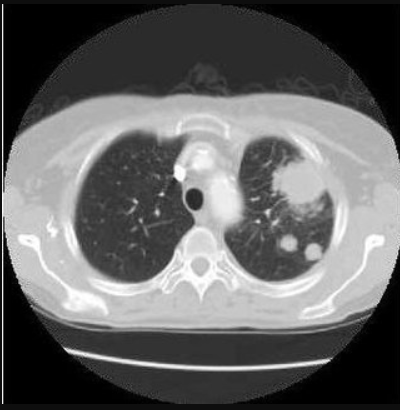

In [ ]:
from PIL import Image

print("Upload your image:")
uploaded_img = files.upload()

image_path = list(uploaded_img.keys())[0]
image = Image.open(image_path).convert("RGB")

image

In [ ]:
import torch.nn.functional as F
import numpy as np

similarities = []

for chunk in text_chunks:
    inputs = processor(
        text=[chunk],
        images=image,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        image_embeds = F.normalize(outputs.image_embeds, p=2, dim=-1)
        text_embeds = F.normalize(outputs.text_embeds, p=2, dim=-1)

        score = (image_embeds @ text_embeds.T).item()
        similarities.append(score)

max_similarity = max(similarities)

print("\n🎯 Maximum Cosine Similarity:", round(max_similarity, 4))


🎯 Maximum Cosine Similarity: 0.3264


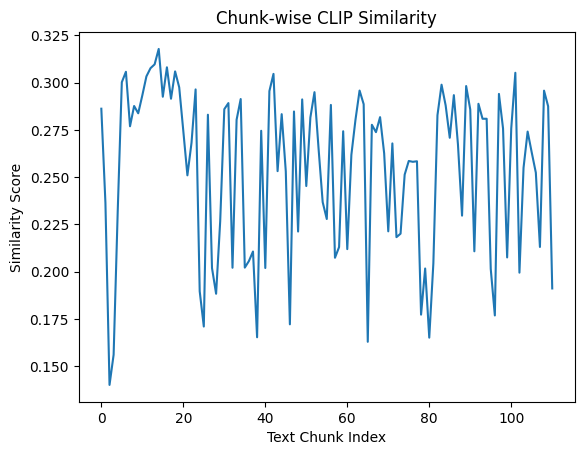

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(similarities)
plt.xlabel("Text Chunk Index")
plt.ylabel("Similarity Score")
plt.title("Chunk-wise CLIP Similarity")
plt.show()

In [ ]:
def explain_similarity(score):
    if score > 0.75:
        return "The image strongly matches the semantic meaning of the document."
    elif score > 0.4:
        return "The image has moderate semantic similarity with the document."
    else:
        return "The image has weak semantic similarity with the document."
print("\n📘 Explanation:")
print(explain_similarity(max_similarity))


📘 Explanation:
The image has weak semantic similarity with the document.


In [ ]:
import re

def extract_entities(text):
    words = text.split()
    entities = [w for w in words if w.istitle()]
    return list(set(entities[:20]))

def detect_intent(text):
    if "detect" in text.lower() or "diagnosis" in text.lower():
        return "Medical Diagnosis"
    elif "classification" in text.lower():
        return "Classification Task"
    elif "machine learning" in text.lower():
        return "Machine Learning Research"
    else:
        return "General Research"

entities = extract_entities(text_data)
intent = detect_intent(text_data)

print("\n🧠 Extracted Entities:")
print(entities)

print("\n🎯 Detected Intent:")
print(intent)


🧠 Extracted Entities:
['Technology', 'October', 'Detection', 'Abid', 'The', 'Article', 'Learning', 'See', 'Techniques', 'Lung', 'Cancer', 'Women', 'Engineering', 'University', 'Supervised', 'Muhammad', 'Machine', 'Laiba', 'Institute', 'Rehman']

🎯 Detected Intent:
Medical Diagnosis
